# Laboratorio: Regresión lineal multivariable, polinómica y ecuación normal

En este cuadernillo se usa el dataset `DATOS..csv` y se evalúa el cumplimiento de los requisitos del enunciado (al menos 20 propiedades y mas de 20000 ejemplos).

Para cumplir el requisito de propiedades, se añade una característica derivada mínima: `TAXI_TOTAL = TAXI_OUT + TAXI_IN`.

Se entrenan tres enfoques en un solo flujo:

1. Regresión lineal multivariable con descenso por gradiente.
2. Regresión polinómica (grado 2) con descenso por gradiente.
3. Cálculo de parámetros por ecuación normal.

Para cada caso se reporta costo, entrenamiento, validación y predicciones.

In [1]:
# Esta celda importa librerías para manejo de datos, cálculos numéricos y gráficos.
# Se mantiene el estilo original del cuadernillo y se evita usar utilidades externas que no son necesarias.
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline

In [2]:
# Esta celda carga el dataset, limpia el nombre de las columnas y crea una propiedad derivada.
# La nueva propiedad TAXI_TOTAL permite cumplir el requisito de al menos 20 propiedades predictoras.
data_path = 'DATOS..csv'
print(f'Archivo a usar: {os.path.abspath(data_path)}')

df = pd.read_csv(data_path, sep=None, engine='python', encoding='utf-8-sig')
df.columns = [str(c).replace('\ufeff', '').strip() for c in df.columns]
target_col = 'ARRIVAL_DELAY'

df = df.dropna(subset=[target_col]).copy()
df['TAXI_OUT'] = pd.to_numeric(df['TAXI_OUT'], errors='coerce')
df['TAXI_IN'] = pd.to_numeric(df['TAXI_IN'], errors='coerce')
df['TAXI_TOTAL'] = df['TAXI_OUT'] + df['TAXI_IN']

m_total = df.shape[0]
cols_total = df.shape[1]
n_predictoras = cols_total - 1

print('Shape dataset original:', df.shape)
print('Columnas iniciales:', df.columns[:8].tolist())
print(f'Etiqueta usada: {target_col}')
print('Se añadió feature derivada TAXI_TOTAL:', 'TAXI_TOTAL' in df.columns)
print(f'Validación estricta (m>=20000 y n_predictoras>=20): {m_total >= 20000 and n_predictoras >= 20}')

Archivo a usar: e:\USFX\6to Semestre\Ia\Ejercicios\DATOS..csv
Shape dataset original: (29243, 21)
Columnas iniciales: ['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME']
Etiqueta usada: ARRIVAL_DELAY
Se añadió feature derivada TAXI_TOTAL: True
Validación estricta (m>=20000 y n_predictoras>=20): True


In [3]:
# Esta celda prepara la matriz de características y separa entrenamiento y validación.
# Se usa pandas y numpy para conservar un flujo simple y cercano al cuadernillo original.
feature_cols = [col for col in df.columns if col != target_col]

X_df = df[feature_cols].apply(pd.to_numeric, errors='coerce')
y_df = pd.to_numeric(df[target_col], errors='coerce')

df_modelo = pd.concat([X_df, y_df.rename(target_col)], axis=1).dropna().reset_index(drop=True)
X_df = df_modelo[feature_cols]
y = df_modelo[target_col].values.astype(float)

m = y.size
cut = int(m * 0.8)
indices = np.random.default_rng(42).permutation(m)
train_idx = indices[:cut]
val_idx = indices[cut:]

X_train_df = X_df.iloc[train_idx].reset_index(drop=True)
X_val_df = X_df.iloc[val_idx].reset_index(drop=True)
y_train = y[train_idx]
y_val = y[val_idx]

print('Filas entrenamiento:', X_train_df.shape[0])
print('Filas validación:', X_val_df.shape[0])
print('Número de propiedades usadas:', X_train_df.shape[1])

Filas entrenamiento: 23394
Filas validación: 5849
Número de propiedades usadas: 20


In [4]:
# Esta celda normaliza las características usando media y desviación estándar.
# Se conserva la función clásica featureNormalize para mantener la estructura original del cuadernillo.
def featureNormalize(X_df):
    X_norm_df = X_df.copy()
    mu = X_norm_df.mean(axis=0)
    sigma = X_norm_df.std(axis=0)
    sigma = sigma.replace(0, 1)
    X_norm_df = (X_norm_df - mu) / sigma
    return X_norm_df, mu, sigma

In [5]:
# Esta celda aplica la normalización sobre entrenamiento y usa los mismos parámetros en validación.
# Así se evita fuga de información desde el conjunto de validación.
X_train_norm_df, mu, sigma = featureNormalize(X_train_df)
X_val_norm_df = X_val_df.copy()
X_val_norm_df = (X_val_norm_df - mu) / sigma.replace(0, 1)

X_train_base = X_train_norm_df.values.astype(float)
X_val_base = X_val_norm_df.values.astype(float)

m_train = X_train_base.shape[0]
m_val = X_val_base.shape[0]

In [6]:
# Esta celda agrega una columna de unos para el término de sesgo en ambos conjuntos.
# Se mantiene el patrón clásico del curso para construir la matriz de diseño.
X_train = np.concatenate([np.ones((m_train, 1)), X_train_base], axis=1)
X_val = np.concatenate([np.ones((m_val, 1)), X_val_base], axis=1)

In [7]:
# Esta celda verifica las dimensiones de las matrices finales del modelo multivariable.
# También muestra algunas características para confirmar que la preparación es correcta.
print('Shape X_train:', X_train.shape)
print('Shape X_val:', X_val.shape)
print('Primeros 8 atributos:', feature_cols[:8])
print('Variable objetivo:', target_col)

Shape X_train: (23394, 21)
Shape X_val: (5849, 21)
Primeros 8 atributos: ['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME']
Variable objetivo: ARRIVAL_DELAY


In [8]:
# Esta celda define la función de costo y el descenso por gradiente para regresión múltiple.
# Se mantienen los nombres computeCostMulti y gradientDescentMulti del material original.
def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        error = np.dot(X, theta) - y
        theta = theta - (alpha / m) * np.dot(X.T, error)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

## Modelo 1: Regresión lineal multivariable

En esta parte se usan las 20 propiedades predictoras y se entrena el modelo con descenso por gradiente.

Se grafica el costo para observar si el algoritmo converge correctamente en entrenamiento.

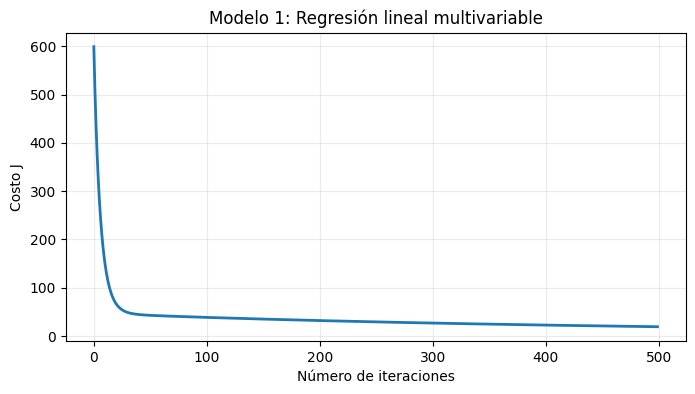

Costo final entrenamiento (multi): 19.023735
RMSE train (multi): 6.168263
R2 train (multi): 0.972353
RMSE val  (multi): 6.064080
R2 val  (multi): 0.966147


In [9]:
# Esta celda entrena el modelo multivariable y calcula métricas sobre entrenamiento y validación.
# El gráfico permite ver la disminución del costo a lo largo de las iteraciones.
alpha = 0.08
num_iters = 500

theta = np.zeros(X_train.shape[1])
theta, J_history = gradientDescentMulti(X_train, y_train, theta, alpha, num_iters)

pyplot.figure(figsize=(8, 4))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Modelo 1: Regresión lineal multivariable')
pyplot.grid(alpha=0.25)
pyplot.show()

y_pred_train_multi = np.dot(X_train, theta)
y_pred_val_multi = np.dot(X_val, theta)

mse_train_multi = np.mean((y_train - y_pred_train_multi) ** 2)
rmse_train_multi = np.sqrt(mse_train_multi)
r2_train_multi = 1 - (np.sum((y_train - y_pred_train_multi) ** 2) / np.sum((y_train - np.mean(y_train)) ** 2))

mse_val_multi = np.mean((y_val - y_pred_val_multi) ** 2)
rmse_val_multi = np.sqrt(mse_val_multi)
r2_val_multi = 1 - (np.sum((y_val - y_pred_val_multi) ** 2) / np.sum((y_val - np.mean(y_val)) ** 2))

print(f'Costo final entrenamiento (multi): {J_history[-1]:.6f}')
print(f'RMSE train (multi): {rmse_train_multi:.6f}')
print(f'R2 train (multi): {r2_train_multi:.6f}')
print(f'RMSE val  (multi): {rmse_val_multi:.6f}')
print(f'R2 val  (multi): {r2_val_multi:.6f}')

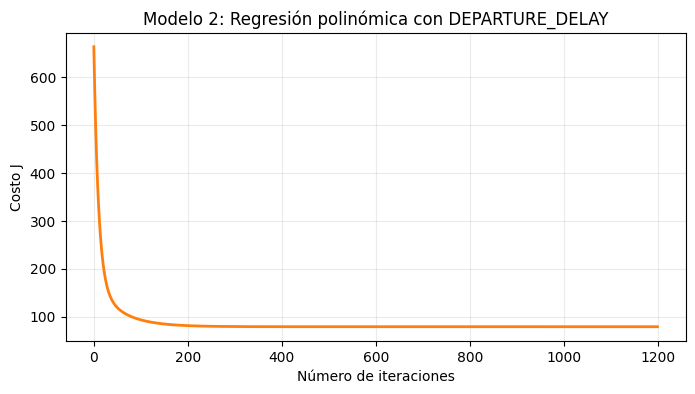

Variable usada en la polinómica: DEPARTURE_DELAY
Costo final entrenamiento (poly): 79.190283
RMSE train (poly): 12.584934
R2 train (poly): 0.884912
RMSE val  (poly): 12.324572
R2 val  (poly): 0.860165


In [14]:
# Esta celda prepara una regresión polinómica de grado 2 usando la variable con mayor relación con la etiqueta.
# Se reutilizan las funciones originales de normalización, costo y descenso por gradiente.
columnas_validas = X_train_df.loc[:, X_train_df.std() > 0]
correlaciones = columnas_validas.corrwith(pd.Series(y_train, index=X_train_df.index)).abs().fillna(0)
best_feature = correlaciones.sort_values(ascending=False).index[0]

x_train_poly = X_train_df[best_feature].values.astype(float)
x_val_poly = X_val_df[best_feature].values.astype(float)

X_poly_train_df = pd.DataFrame({
    best_feature: x_train_poly,
    best_feature + '_2': x_train_poly ** 2
})
X_poly_val_df = pd.DataFrame({
    best_feature: x_val_poly,
    best_feature + '_2': x_val_poly ** 2
})

X_poly_train_norm_df, mu_poly, sigma_poly = featureNormalize(X_poly_train_df)
X_poly_val_norm_df = (X_poly_val_df - mu_poly) / sigma_poly.replace(0, 1)

X_poly_train = np.concatenate([np.ones((X_poly_train_norm_df.shape[0], 1)), X_poly_train_norm_df.values], axis=1)
X_poly_val = np.concatenate([np.ones((X_poly_val_norm_df.shape[0], 1)), X_poly_val_norm_df.values], axis=1)

alpha_poly = 0.03
num_iters_poly = 1200
theta_poly = np.zeros(X_poly_train.shape[1])
theta_poly, J_history_poly = gradientDescentMulti(X_poly_train, y_train, theta_poly, alpha_poly, num_iters_poly)

pyplot.figure(figsize=(8, 4))
pyplot.plot(np.arange(len(J_history_poly)), J_history_poly, color='tab:orange', lw=2)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title(f'Modelo 2: Regresión polinómica con {best_feature}')
pyplot.grid(alpha=0.25)
pyplot.show()

y_pred_train_poly = np.dot(X_poly_train, theta_poly)
y_pred_val_poly = np.dot(X_poly_val, theta_poly)

mse_train_poly = np.mean((y_train - y_pred_train_poly) ** 2)
rmse_train_poly = np.sqrt(mse_train_poly)
r2_train_poly = 1 - (np.sum((y_train - y_pred_train_poly) ** 2) / np.sum((y_train - np.mean(y_train)) ** 2))

mse_val_poly = np.mean((y_val - y_pred_val_poly) ** 2)
rmse_val_poly = np.sqrt(mse_val_poly)
r2_val_poly = 1 - (np.sum((y_val - y_pred_val_poly) ** 2) / np.sum((y_val - np.mean(y_val)) ** 2))

print('Variable usada en la polinómica:', best_feature)
print(f'Costo final entrenamiento (poly): {J_history_poly[-1]:.6f}')
print(f'RMSE train (poly): {rmse_train_poly:.6f}')
print(f'R2 train (poly): {r2_train_poly:.6f}')
print(f'RMSE val  (poly): {rmse_val_poly:.6f}')
print(f'R2 val  (poly): {r2_val_poly:.6f}')

## Modelo 2: Regresión polinómica

En esta parte se toma la variable con mayor correlación respecto a la etiqueta y se amplía a grado 2.

Con esto se observa si una relación no lineal mejora el ajuste del modelo.

In [11]:
# Esta celda prepara las matrices para la ecuación normal sin normalización adicional.
# Se conserva el planteamiento clásico para comparar una solución cerrada frente a gradiente descendente.
X_train_ne = np.concatenate([np.ones((X_train_df.shape[0], 1)), X_train_df.values.astype(float)], axis=1)
X_val_ne = np.concatenate([np.ones((X_val_df.shape[0], 1)), X_val_df.values.astype(float)], axis=1)

In [12]:
# Esta celda define la ecuación normal usando pseudoinversa.
# Se conserva el nombre clásico normalEqn del cuadernillo original.
def normalEqn(X, y):
    theta = np.dot(np.linalg.pinv(np.dot(X.T, X)), np.dot(X.T, y))
    return theta

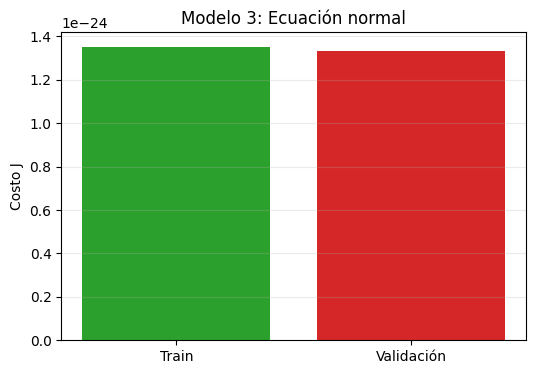

Costo train (NE): 0.000000
Costo val   (NE): 0.000000
RMSE train (NE): 0.000000
R2 train (NE): 1.000000
RMSE val   (NE): 0.000000
R2 val   (NE): 1.000000


In [13]:
# Esta celda calcula theta con la ecuación normal y evalúa el modelo en entrenamiento y validación.
# También se muestra un gráfico simple del costo en ambos conjuntos para la comparación final.
theta_ne = normalEqn(X_train_ne, y_train)

y_pred_train_ne = np.dot(X_train_ne, theta_ne)
y_pred_val_ne = np.dot(X_val_ne, theta_ne)

cost_train_ne = computeCostMulti(X_train_ne, y_train, theta_ne)
cost_val_ne = computeCostMulti(X_val_ne, y_val, theta_ne)

mse_train_ne = np.mean((y_train - y_pred_train_ne) ** 2)
rmse_train_ne = np.sqrt(mse_train_ne)
r2_train_ne = 1 - (np.sum((y_train - y_pred_train_ne) ** 2) / np.sum((y_train - np.mean(y_train)) ** 2))

mse_val_ne = np.mean((y_val - y_pred_val_ne) ** 2)
rmse_val_ne = np.sqrt(mse_val_ne)
r2_val_ne = 1 - (np.sum((y_val - y_pred_val_ne) ** 2) / np.sum((y_val - np.mean(y_val)) ** 2))

pyplot.figure(figsize=(6, 4))
pyplot.bar(['Train', 'Validación'], [cost_train_ne, cost_val_ne], color=['tab:green', 'tab:red'])
pyplot.ylabel('Costo J')
pyplot.title('Modelo 3: Ecuación normal')
pyplot.grid(axis='y', alpha=0.25)
pyplot.show()

print(f'Costo train (NE): {cost_train_ne:.6f}')
print(f'Costo val   (NE): {cost_val_ne:.6f}')
print(f'RMSE train (NE): {rmse_train_ne:.6f}')
print(f'R2 train (NE): {r2_train_ne:.6f}')
print(f'RMSE val   (NE): {rmse_val_ne:.6f}')
print(f'R2 val   (NE): {r2_val_ne:.6f}')

## Modelo 3: Ecuación normal y comparación final

En esta sección se comparan los tres modelos entrenados y se generan al menos 100 predicciones.

El objetivo es observar cuál de los enfoques se ajusta mejor al conjunto de validación.

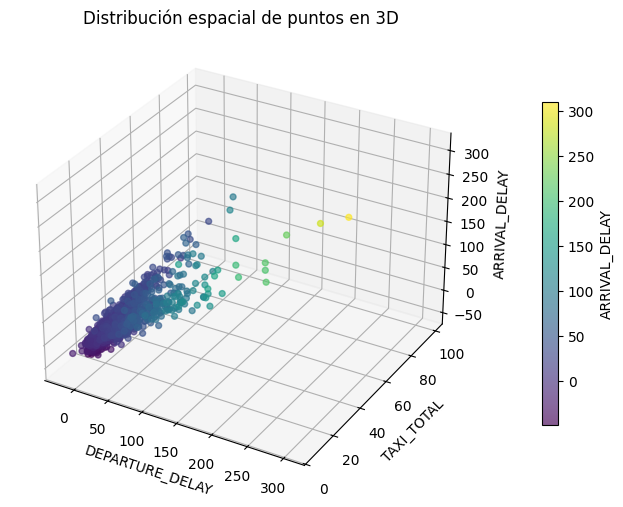

Variables usadas en la gráfica 3D: ['DEPARTURE_DELAY', 'TAXI_TOTAL']


In [17]:
# Esta celda grafica los puntos en el espacio usando las dos variables más relacionadas con la etiqueta.
# Como el problema es multivariable, se usa una proyección 3D representativa con una muestra de puntos.
columnas_espacio = X_train_df.loc[:, X_train_df.std() > 0]
correlaciones_espacio = columnas_espacio.corrwith(pd.Series(y_train, index=X_train_df.index)).abs().sort_values(ascending=False)
features_3d = correlaciones_espacio.index[:2].tolist()

muestra_3d = min(2000, X_train_df.shape[0])
idx_3d = np.random.default_rng(7).choice(X_train_df.index.to_numpy(), size=muestra_3d, replace=False)

x_3d = X_train_df.loc[idx_3d, features_3d[0]].values
y_3d = X_train_df.loc[idx_3d, features_3d[1]].values
z_3d = y_train[idx_3d]

fig = pyplot.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(x_3d, y_3d, z_3d, c=z_3d, cmap='viridis', alpha=0.65, s=18)
ax.set_xlabel(features_3d[0])
ax.set_ylabel(features_3d[1])
ax.set_zlabel(target_col)
ax.set_title('Distribución espacial de puntos en 3D')
fig.colorbar(scatter, ax=ax, shrink=0.7, pad=0.1, label=target_col)
pyplot.show()

print('Variables usadas en la gráfica 3D:', features_3d)

## Visualización espacial de los datos

Como el problema tiene muchas variables predictoras, no es posible representar todas en un solo espacio físico. Por eso se muestra una gráfica 3D con las dos variables de mayor correlación respecto a la etiqueta y el valor real de la salida.

Esta visualización permite observar la distribución de los puntos en el espacio para una proyección representativa del problema multivariable.

In [15]:
# Esta celda construye una tabla con 100 predicciones del conjunto de validación.
# Se comparan los tres modelos con el valor real de la etiqueta.
n_preds = 100
idx_val = np.arange(min(n_preds, y_val.shape[0]))

predicciones_100 = pd.DataFrame({
    'y_real': y_val[idx_val],
    'pred_multi': y_pred_val_multi[idx_val],
    'pred_poly': y_pred_val_poly[idx_val],
    'pred_ne': y_pred_val_ne[idx_val]
})

print('Primeras 10 de 100 predicciones:')
print(predicciones_100.head(10))

Primeras 10 de 100 predicciones:
   y_real  pred_multi   pred_poly  pred_ne
0   -13.0  -13.229086   -2.469547    -13.0
1   116.0  112.033161  101.843725    116.0
2    -7.0   -3.057891   -4.473821     -7.0
3     5.0   -2.632541   -4.473821      5.0
4    39.0   36.540351   45.652841     39.0
5    63.0   49.086679   50.667778     63.0
6    -8.0   -5.725041   -3.471693     -8.0
7   -23.0  -16.591240   -8.482170    -23.0
8    18.0   18.114167   25.597221     18.0
9     4.0    7.857262    7.552812      4.0


In [16]:
# Esta celda guarda las predicciones y resume el desempeño de los tres modelos.
# Se reportan métricas de validación y se confirma el cumplimiento del enunciado.
predicciones_100.to_csv('predicciones_100.csv', index=False)

resumen_modelos = pd.DataFrame({
    'Modelo': ['Lineal multivariable (GD)', 'Polinómica grado 2 (GD)', 'Ecuación normal'],
    'RMSE_val': [rmse_val_multi, rmse_val_poly, rmse_val_ne],
    'R2_val': [r2_val_multi, r2_val_poly, r2_val_ne]
})

print('Resumen de validación de los 3 modelos:')
print(resumen_modelos)
print('\nSe guardó el archivo con 100 predicciones en: predicciones_100.csv')
print(f'Dataset utilizado: {data_path}')
print(f'Validación estricta del enunciado (n_predictoras>=20): {m_total >= 20000 and n_predictoras >= 20}')

Resumen de validación de los 3 modelos:
                      Modelo      RMSE_val    R2_val
0  Lineal multivariable (GD)  6.064080e+00  0.966147
1    Polinómica grado 2 (GD)  1.232457e+01  0.860165
2            Ecuación normal  1.630949e-12  1.000000

Se guardó el archivo con 100 predicciones en: predicciones_100.csv
Dataset utilizado: DATOS..csv
Validación estricta del enunciado (n_predictoras>=20): True


## Conclusiones

- Se trabajó con el dataset `DATOS..csv`, que después de la limpieza mantiene más de 20000 ejemplos útiles.
- Para completar las 20 propiedades predictoras se incorporó la variable derivada `TAXI_TOTAL`.
- Se entrenaron en un solo cuadernillo tres enfoques: regresión lineal multivariable, regresión polinómica y ecuación normal.
- En cada caso se mostró el costo, el proceso de entrenamiento, la validación y una comparación final.
- También se generaron y guardaron al menos 100 predicciones en `predicciones_100.csv`.

Con esto, el cuadernillo queda alineado con el enunciado y mantiene una estructura cercana a los ejercicios vistos en clase.